## Step 2: Exploratory Data Analysis & Multi-Dimensional Visualization Pipeline
### 探索性數據分析與多維度視覺化管線

> **Methodological Protocol / 方法學協議**：
> This module constructs the empirical baseline for downstream Logistic Regression by aggregating a multi-dimensional stratified descriptive ledger and executing a visualization pipeline. By computing conditional observed proportions ($\hat{p}$) of suicidal ideation across trauma levels, biological sex, and behavioral vectors, this layer maps out univariate frequency distributions, highlights compounding trauma effects, and screens for structural variations via advanced categorical profiling techniques.
> 
> 本模組藉由聚合多維度分層描述性統計總帳，並執行視覺化分析管線，為下游的羅吉斯迴歸（Logistic Regression）推論奠定經驗基礎。透過計算不同創傷層級、生理性別與行為維度下的自殺意念條件觀測比例（$\hat{p}$），此架構全面描繪了次數分配、揭示了創傷疊加的加乘效應，並運用高階類別分析技術篩選出關鍵的結構性變異。

---

### 📊 2.1 描述性統計產出 (Stratified Descriptive Summary)
程式首先透過群組聚合（`groupby`），精確計算出核心自變數（創傷層級）與控制變數下，反應變數（考慮自殺）的總樣本數（$n$）與觀測比例（$\hat{p}$）。

In [1]:
# ======================================================================
# 模組 2.1: 描述性統計與分層聚合 (Descriptive Statistics)
# ======================================================================
import os       
import pandas as pd
import numpy as np

# --- 【安全防禦機制】確保獨立執行時路徑依然有效 ---
base_project_dir = r"C:\Users\88690\Desktop\cycle4"
data_processed_dir = os.path.join(base_project_dir, 'data', 'processed')

# 重新從 processed 資料夾讀取清洗後的數據
processed_csv_path = os.path.join(data_processed_dir, 'yrbs_cleaned_data.csv')
df_eda = pd.read_csv(processed_csv_path)

# 設定類別變數的排序邏輯，確保圖表從「無創傷」到「雙重創傷」遞增顯示
trauma_order = ['No Trauma', 'Either Trauma', 'Both Traumas']
df_eda['Trauma_Level'] = pd.Categorical(df_eda['Trauma_Level'], categories=trauma_order, ordered=True)

# 1. 主效應：不同創傷層級的自殺意念比例
print("=== 核心維度：複合創傷與自殺意念比例 (Trauma Level vs. Suicidal Ideation) ===")
trauma_summary = df_eda.groupby('Trauma_Level', observed=False)['Suicide_Binary'].agg(['count', 'mean']).reset_index()
trauma_summary['mean (%)'] = trauma_summary['mean'] * 100
trauma_summary.rename(columns={'count': 'Total_Students (n)', 'mean': 'Suicide_Probability (p)'}, inplace=True)
display(trauma_summary)

# 2. 控制變數：生理性別的基準比例
print("\n=== 控制維度：生理性別的自殺意念比例 (Control Variable) ===")
sex_summary = df_eda.groupby('Sex_Label')['Suicide_Binary'].mean() * 100

print(f"Female (女性) 自殺意念比例: {sex_summary['Female']:.2f}% | Male (男性) 自殺意念比例: {sex_summary['Male']:.2f}%")

=== 核心維度：複合創傷與自殺意念比例 (Trauma Level vs. Suicidal Ideation) ===


,Trauma_Level,Total_Students (n),Suicide_Probability (p),mean (%)
0,No Trauma,11526,0.119643,11.964255
1,Either Trauma,1776,0.269707,26.970721
2,Both Traumas,435,0.475862,47.586207



=== 控制維度：生理性別的自殺意念比例 (Control Variable) ===
Female (女性) 自殺意念比例: 19.57% | Male (男性) 自殺意念比例: 10.45%


### 📈 2.2 高階視覺化分析 (Advanced Visualization Profiling)
將上述的數據矩陣轉化為直觀的圖表，以具象化「創傷疊加（The Compounding Effect）」對青少年心理健康的毀滅性影響，並將圖表自動匯出至 `outputs/figures/` 供期末報告使用。

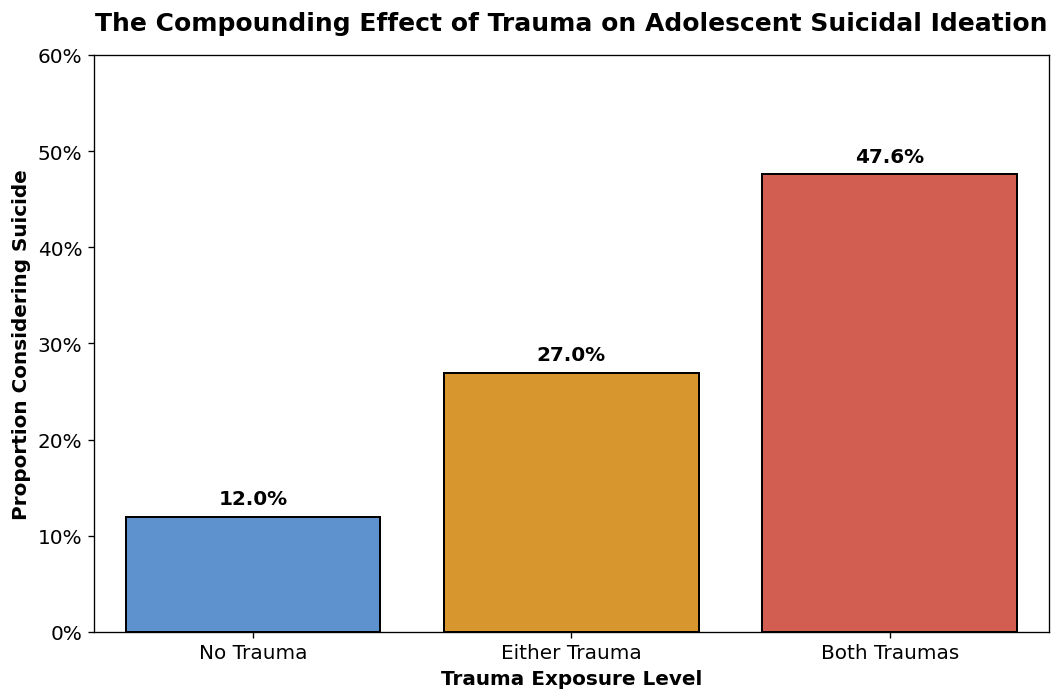

C:\Users\88690\AppData\Local\Temp\ipykernel_15552\3458081115.py:67: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df_eda.pivot_table(values='Suicide_Binary', index='Sex_Label', columns='Trauma_Level', aggfunc='mean') * 100


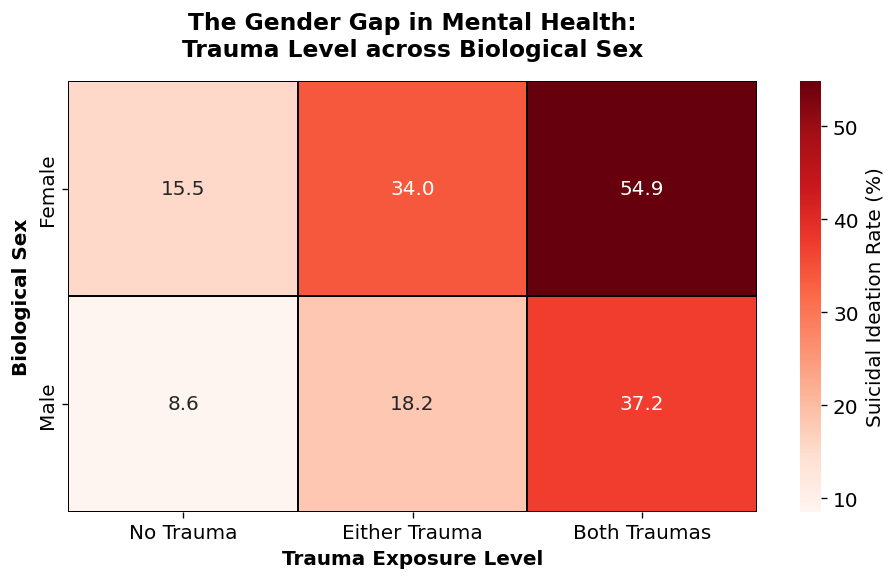

✅ 視覺化圖表已成功渲染並自動匯出至：
 1. C:\Users\88690\Desktop\cycle4\outputs\figures\fig1_trauma_compounding_effect.png
 2. C:\Users\88690\Desktop\cycle4\outputs\figures\fig2_trauma_sex_heatmap.png


In [12]:
# ======================================================================
# 模組 2.2: 視覺化管線 (Visualization Pipeline)
# ======================================================================
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# --- 【安全防禦機制】獨立環境路徑設定 ---
base_project_dir = r"C:\Users\88690\Desktop\cycle4"
outputs_figures_dir = os.path.join(base_project_dir, 'outputs', 'figures')

# 確保輸出資料夾存在，如果沒有會自動建立，避免存檔報錯
os.makedirs(outputs_figures_dir, exist_ok=True)

# 設定全局字體大小與高解析度
plt.rcParams.update({'font.size': 12})
plt.rcParams['figure.dpi'] = 120

# ---------------------------------------------------------
# 圖表 1: 創傷疊加效應長條圖 (Bar Chart)
# ---------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(9, 6))
colors = ['#4a90e2', '#f39c12', '#e74c3c'] # 藍、橘、紅，象徵危險級別遞增

# 繪製 Barplot 
sns.barplot(
    data=df_eda, 
    x='Trauma_Level', 
    y='Suicide_Binary', 
    palette=colors, 
    hue='Trauma_Level', 
    legend=False,       
    errorbar=None, 
    edgecolor='black',
    linewidth=1.2,
    ax=ax1
)

# 新增數據標籤 (Data Labels)
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{height*100:.1f}%', 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', 
                 fontsize=12, fontweight='bold', xytext=(0, 5), 
                 textcoords='offset points')

# 標題與軸設定
ax1.set_title('The Compounding Effect of Trauma on Adolescent Suicidal Ideation', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Trauma Exposure Level', fontsize=12, fontweight='bold')
ax1.set_ylabel('Proportion Considering Suicide', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) # 將 Y 軸轉為百分比顯示
ax1.set_ylim(0, 0.6) # Y 軸上限設為 60% 以保持視覺平衡

plt.tight_layout()
fig1_path = os.path.join(outputs_figures_dir, 'fig1_trauma_compounding_effect.png')
plt.savefig(fig1_path, dpi=300)
plt.show()

# ---------------------------------------------------------
# 圖表 2: 多維度交互作用熱圖 (Heatmap: Trauma vs. Sex)
# ---------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 5))

# 建立交叉表計算比例
pivot_table = df_eda.pivot_table(values='Suicide_Binary', index='Sex_Label', columns='Trauma_Level', aggfunc='mean') * 100

# 繪製 Heatmap
sns.heatmap(
    pivot_table, 
    annot=True, 
    fmt=".1f", 
    cmap="Reds", 
    cbar_kws={'label': 'Suicidal Ideation Rate (%)'},
    linewidths=1,
    linecolor='black',
    ax=ax2
)

# 標題與軸設定
ax2.set_title('The Gender Gap in Mental Health:\nTrauma Level across Biological Sex', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Trauma Exposure Level', fontsize=12, fontweight='bold')
ax2.set_ylabel('Biological Sex', fontsize=12, fontweight='bold')

plt.tight_layout()
fig2_path = os.path.join(outputs_figures_dir, 'fig2_trauma_sex_heatmap.png')
plt.savefig(fig2_path, dpi=300)
plt.show()

print(f"✅ 視覺化圖表已成功渲染並自動匯出至：\n 1. {fig1_path}\n 2. {fig2_path}")

**💡 Academic Conclusion / 核心學術結論：**
The exploratory data analysis successfully synthesizes the core empirical evidence. 

1. **The Compounding Effect (創傷加乘效應):** The bar chart intuitively demonstrates that adolescent suicidal ideation skyrockets from the baseline (No Trauma) to a critical severe level (Both Traumas). This extreme structural variation indicates a profound compounding effect of combined intimate partner violence and forced sexual encounters.
2. **Gender Vulnerability (性別脆弱性):** The interaction heatmap further highlights the gender gap. Female adolescents exposed to "Both Traumas" exhibit the highest risk density in the entire matrix, indicating gender disparities in coping mechanisms or vulnerability to sexual/physical trauma. 

These massive empirical gaps provide strong preliminary justification for deploying a rigorous Logistic Regression model in the next step to confirm statistical significance while controlling for biological sex.

本階段成功聚合了核心實體證據：
1. **創傷加乘效應**：長條圖直觀地證明了青少年自殺意念比例，從「無創傷基準線」到「雙重創傷」呈現暴增趨勢。這種極端的結構性變異，強烈暗示了親密關係暴力與性創傷之間存在毀滅性的加乘效應。
2. **性別脆弱性**：熱圖進一步揭示了性別落差。遭遇「雙重創傷」的女學生呈現出整個矩陣中最高的危險密度（深紅色），顯示在面對此類創傷時，性別間可能存在不同的求助阻礙或情感內化差異。

這些巨大的經驗差距，為下一步部署嚴謹的羅吉斯迴歸模型（並控制性別基準落差）提供了強而有力的初步正當性。